In [12]:
# -*- coding: utf-8 -*-
"""Прогноз потребности в менторах Mentorhub

Описание: Анализ динамики активных пользователей и прогноз
         необходимого числа менторов при росте менти на 500 человек.
"""

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Настройка стиля
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

# Загрузка данных
df = pd.read_csv('mentor_monthly.csv', parse_dates=['month'])
df.set_index('month', inplace=True)

print("=== Данные загружены ===")
print(f"Период: с {df.index.min().strftime('%B %Y')} по {df.index.max().strftime('%B %Y')}")
print(f"Всего месяцев: {len(df)}")
print("\nПервые 5 строк:")
df.head()

=== Данные загружены ===
Период: с February 2021 по September 2022
Всего месяцев: 20

Первые 5 строк:


,active_mentors,active_mentees
month,,
2021-02-01,3,3
2021-03-01,3,3
2021-04-01,7,7
2021-05-01,18,19
2021-06-01,24,27


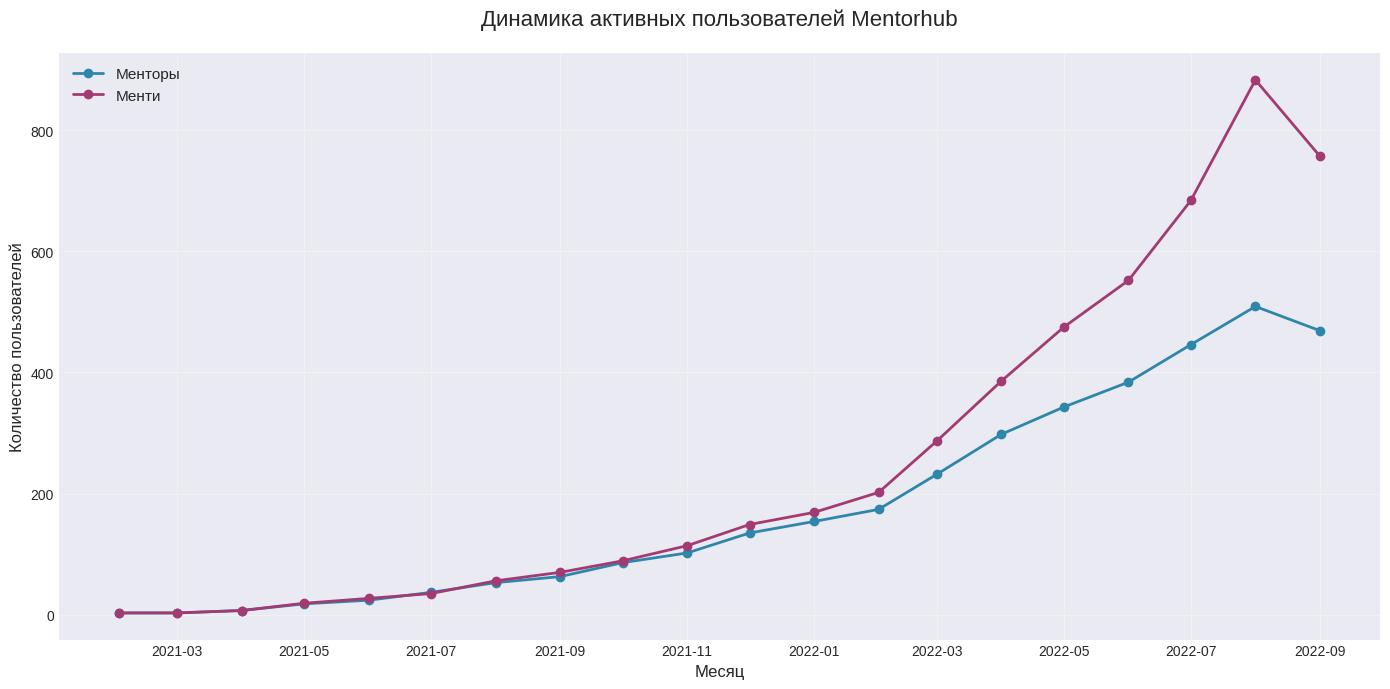

In [6]:
plt.figure(figsize=(14, 7))
plt.plot(df.index, df.active_mentors, 'o-', linewidth=2, markersize=6,
         label='Менторы', color='#2E86AB')
plt.plot(df.index, df.active_mentees, 'o-', linewidth=2, markersize=6,
         label='Менти', color='#A23B72')

plt.title('Динамика активных пользователей Mentorhub', fontsize=16, pad=20)
plt.xlabel('Месяц', fontsize=12)
plt.ylabel('Количество пользователей', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
# Текущие значения (последний месяц)
current_mentors = df.active_mentors.iloc[-1]
current_mentees = df.active_mentees.iloc[-1]
ratio = current_mentees / current_mentors

print("=== ТЕКУЩЕЕ СОСТОЯНИЕ (сентябрь 2022) ===")
print(f"Активных менторов: {current_mentors}")
print(f"Активных менти:    {current_mentees}")
print(f"На одного ментора приходится {ratio:.2f} менти\n")

# Прогноз по условию задачи
NEW_MENTEES = 500
total_mentees_next = current_mentees + NEW_MENTEES
required_mentors = total_mentees_next / ratio  # обратное соотношение
new_mentors_needed = required_mentors - current_mentors

print("=== ПРОГНОЗ НА СЛЕДУЮЩИЙ МЕСЯЦ ===")
print(f"Текущее число менти:               {current_mentees}")
print(f"Плановый прирост менти:            +{NEW_MENTEES}")
print(f"Прогнозное число менти:             {total_mentees_next:.0f}")
print(f"Требуется менторов (при текущей нагрузке): {required_mentors:.0f}")
print(f"Нужно дополнительно привлечь менторов:     {new_mentors_needed:.0f}")

=== ТЕКУЩЕЕ СОСТОЯНИЕ (сентябрь 2022) ===
Активных менторов: 469
Активных менти:    757
На одного ментора приходится 1.61 менти

=== ПРОГНОЗ НА СЛЕДУЮЩИЙ МЕСЯЦ ===
Текущее число менти:               757
Плановый прирост менти:            +500
Прогнозное число менти:             1257
Требуется менторов (при текущей нагрузке): 779
Нужно дополнительно привлечь менторов:     310


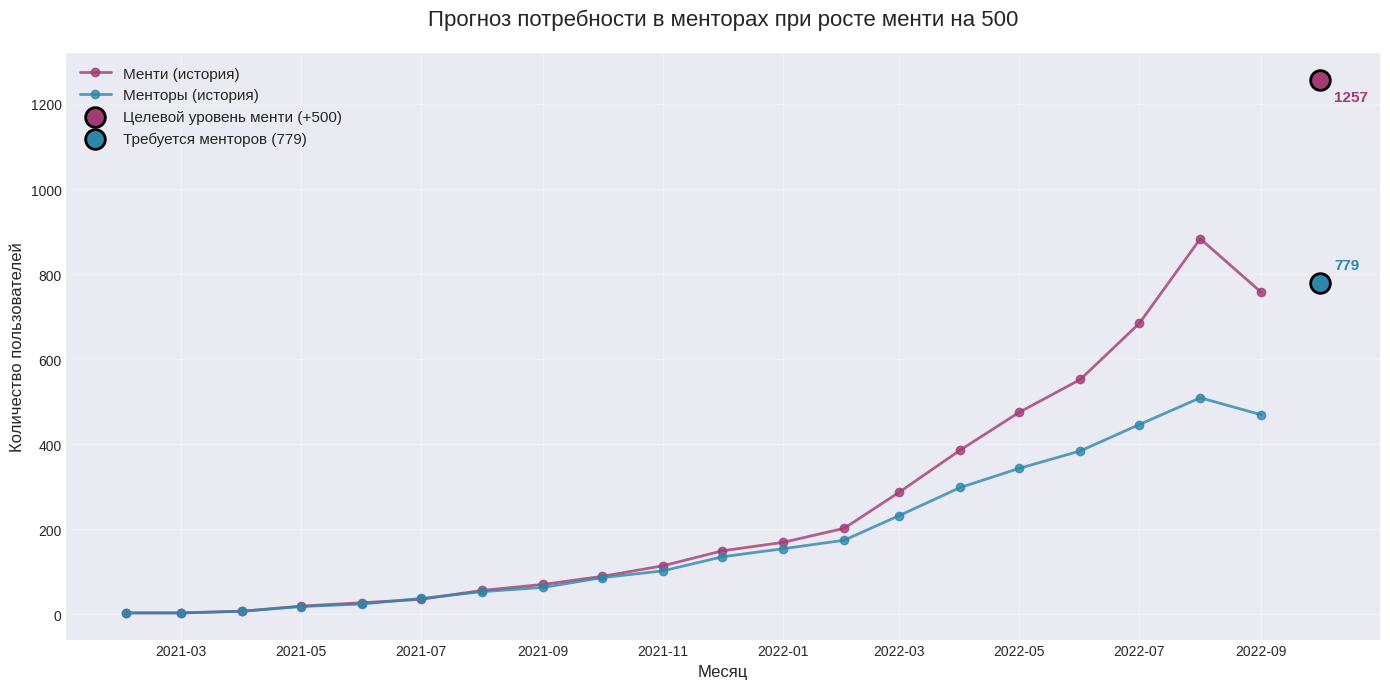

In [13]:
# Создаем дату следующего месяца
next_month = pd.date_range(start=df.index[-1], periods=2, freq='MS')[1]

plt.figure(figsize=(14, 7))

# Исторические данные
plt.plot(df.index, df.active_mentees, 'o-', linewidth=2, markersize=6,
         label='Менти (история)', color='#A23B72', alpha=0.8)
plt.plot(df.index, df.active_mentors, 'o-', linewidth=2, markersize=6,
         label='Менторы (история)', color='#2E86AB', alpha=0.8)

# Прогнозные точки
plt.scatter([next_month], [total_mentees_next], color='#A23B72', s=200,
            zorder=5, edgecolor='black', linewidth=2,
            label=f'Целевой уровень менти (+{NEW_MENTEES})')
plt.scatter([next_month], [required_mentors], color='#2E86AB', s=200,
            zorder=5, edgecolor='black', linewidth=2,
            label=f'Требуется менторов ({required_mentors:.0f})')

# Аннотации (подписи к точкам)
plt.annotate(f'{required_mentors:.0f}',
             xy=(next_month, required_mentors),
             xytext=(10, 10), textcoords='offset points',
             fontsize=11, fontweight='bold', color='#2E86AB')
plt.annotate(f'{total_mentees_next:.0f}',
             xy=(next_month, total_mentees_next),
             xytext=(10, -15), textcoords='offset points',
             fontsize=11, fontweight='bold', color='#A23B72')

plt.title('Прогноз потребности в менторах при росте менти на 500',
          fontsize=16, pad=20)
plt.xlabel('Месяц', fontsize=12)
plt.ylabel('Количество пользователей', fontsize=12)
plt.legend(fontsize=11, loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [14]:
print("""
=== ВЫВОДЫ И РЕКОМЕНДАЦИИ ===

1. Текущая ситуация:
   - На одного ментора приходится 1.61 менти
   - За 1.5 года число менторов выросло с 3 до 469, менти — с 3 до 757
   - Менти растут ощутимо быстрее менторов

2. Прогноз на следующий месяц:
   - При плановом приросте +500 менти потребуется 310 новых менторов
   - Общее число менторов должно увеличиться до 779 (+66% за месяц)
   - Текущая нагрузка на менторов возрастет пропорционально

3. Риски:
   - Без привлечения новых менторов качество сессий может снизиться
   - Наиболее востребованные менторы окажутся перегружены
   - Дисбаланс между спросом и предложением усилится

4. Рекомендации:
   - Начать поиск менторов немедленно
   - Сфокусироваться на направлениях с наибольшим спросом
   - Внедрить программу удержания для существующих менторов
   - Рассмотреть систему бонусов для менторов
""")


=== ВЫВОДЫ И РЕКОМЕНДАЦИИ ===

1. Текущая ситуация:
   - На одного ментора приходится 1.61 менти
   - За 1.5 года число менторов выросло с 3 до 469, менти — с 3 до 757
   - Менти растут ощутимо быстрее менторов

2. Прогноз на следующий месяц:
   - При плановом приросте +500 менти потребуется 310 новых менторов
   - Общее число менторов должно увеличиться до 779 (+66% за месяц)
   - Текущая нагрузка на менторов возрастет пропорционально

3. Риски:
   - Без привлечения новых менторов качество сессий может снизиться
   - Наиболее востребованные менторы окажутся перегружены
   - Дисбаланс между спросом и предложением усилится

4. Рекомендации:
   - Начать поиск менторов немедленно
   - Сфокусироваться на направлениях с наибольшим спросом
   - Внедрить программу удержания для существующих менторов
   - Рассмотреть систему бонусов для менторов

